# Braun 1997 strategy check for BaMgF4

This notebook plots theoretical Maker-fringe curves from `Braun1997Strategy` for the BMF measurement geometries used for each accessible `d_ij` component. The `d_matrix` shape is read from `crystaldatabase`; each plot activates one symbolic component with `d_component`. The Braun nonlinear boundary solve returns the full transmitted SHG intensity directly, so there is no separate analytic `envelope * sin^2(Psi)` split in this notebook.

In [ ]:
import copy
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "test_codes":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [ ]:
%matplotlib inline

from types import SimpleNamespace

from crystaldatabase import CRYSTALS
from fitting_strategies.braun1997 import Braun1997Strategy

In [ ]:
crystal = CRYSTALS["BaMgF4"]()
crystal.d_matrix(kleinmann=False)

Matrix([
[   0,    0,    0,    0, d_15, 0],
[   0,    0,    0, d_24,    0, 0],
[d_31, d_32, d_33,    0,    0, 0]])

In [ ]:
WAVELENGTH_NM = 1064.0
THICKNESS_MM = 10.0
BEAM_DIAMETER_UM = 400.0
THETA_DEG = np.linspace(-20.0, 20.0, 501)

BMF_CONFIGS = [
    {
        "label": "d31",
        "d_component": "d_31",
        "crystal_orientation": "010",
        "rot/trans_axis": "100",
        "input_polarization": 0,
        "detected_polarization": 90,
    },
    {
        "label": "d32",
        "d_component": "d_32",
        "crystal_orientation": "100",
        "rot/trans_axis": "010",
        "input_polarization": 0,
        "detected_polarization": 90,
    },
    {
        "label": "d33, cut 100",
        "d_component": "d_33",
        "crystal_orientation": "100",
        "rot/trans_axis": "001",
        "input_polarization": 0,
        "detected_polarization": 0,
    },
    {
        "label": "d33, cut 010",
        "d_component": "d_33",
        "crystal_orientation": "010",
        "rot/trans_axis": "001",
        "input_polarization": 0,
        "detected_polarization": 0,
    },
    {
        "label": "d15",
        "d_component": "d_15",
        "crystal_orientation": "010",
        "rot/trans_axis": "100",
        "input_polarization": 45,
        "detected_polarization": 0,
    },
    {
        "label": "d24",
        "d_component": "d_24",
        "crystal_orientation": "100",
        "rot/trans_axis": "010",
        "input_polarization": 45,
        "detected_polarization": 0,
    },
]

In [ ]:
def make_analysis(config, theta_deg=THETA_DEG, use_raytrace=False, raytrace_beam_direction="k"):
    meta = {
        "material": "BaMgF4",
        "wavelength_nm": WAVELENGTH_NM,
        "input_polarization": config["input_polarization"],
        "detected_polarization": config["detected_polarization"],
        "crystal_orientation": config["crystal_orientation"],
        "rot/trans_axis": config["rot/trans_axis"],
        "thickness_info": {"t_center_mm": THICKNESS_MM},
        "beam_r_x": BEAM_DIAMETER_UM,
        "beam_r_y": BEAM_DIAMETER_UM,
        "d_component": config["d_component"],
        "use_raytrace": use_raytrace,
        "raytrace_beam_direction": raytrace_beam_direction,
    }
    data = pd.DataFrame(
        {
            "position": theta_deg,
            "intensity_corrected": np.ones_like(theta_deg, dtype=float),
        }
    )
    return SimpleNamespace(meta=meta, data=data)


def calculate_curve(config, use_raytrace=False, envelope=False, raytrace_beam_direction="k"):
    strategy = Braun1997Strategy(
        make_analysis(
            config,
            use_raytrace=use_raytrace,
            raytrace_beam_direction=raytrace_beam_direction,
        )
    )
    override = {
        "use_raytrace": use_raytrace,
        "raytrace_beam_direction": raytrace_beam_direction,
    }
    y, aux = strategy._maker_fringes(override=override, envelope=envelope, return_aux=True)
    return np.asarray(y, dtype=float), aux


In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True)
axes = axes.ravel()

for ax, config in zip(axes, BMF_CONFIGS):
    fringe, aux = calculate_curve(config, use_raytrace=False)
    ax.plot(THETA_DEG, fringe, lw=1.4, label="nonlinear 4x4 solve")
    ax.set_title(
        f"{config['label']} | cut {config['crystal_orientation']} | axis {config['rot/trans_axis']} | "
        f"{config['input_polarization']}->{config['detected_polarization']} deg"
    )
    ax.set_ylabel("normalized intensity")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper right")

for ax in axes[-2:]:
    ax.set_xlabel("external angle (deg)")

fig.tight_layout()

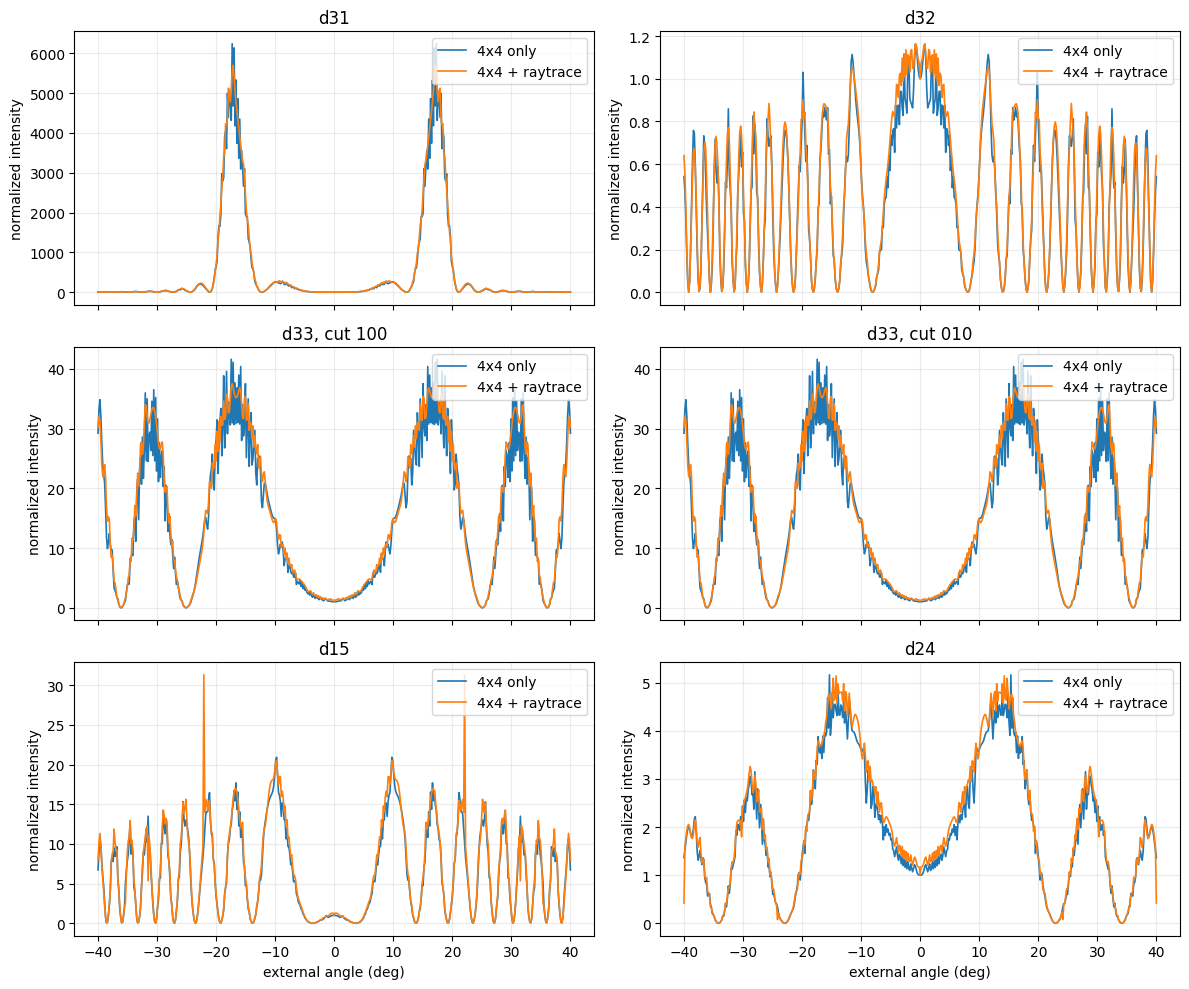

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True)
axes = axes.ravel()

for ax, config in zip(axes, BMF_CONFIGS):
    no_rt, _ = calculate_curve(config, use_raytrace=False)
    with_rt, aux = calculate_curve(config, use_raytrace=True)
    ax.plot(THETA_DEG, no_rt, lw=1.2, label="4x4 only")
    ax.plot(THETA_DEG, with_rt, lw=1.2, label="4x4 + raytrace")
    ax.set_title(config["label"])
    ax.set_ylabel("normalized intensity")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper right")

for ax in axes[-2:]:
    ax.set_xlabel("external angle (deg)")

fig.tight_layout()

## Ray tracing beam-direction comparison

Compare the original Braun Eq. 24 split based on the wave-vector slope (`k`) with an optional split based on the Poynting-vector slope (`poynting`, `Re(E x H*)`).


,label,max_abs_curve_diff,max_abs_bin_width_diff_mm,max_abs_raytrace_factor_diff
0,d31,6.366463e-12,2.220446e-16,4.440892e-16
1,d32,2.442491e-15,2.220446e-16,1.110223e-15
2,"d33, cut 100",3.197442e-14,2.220446e-16,6.661338e-16
3,"d33, cut 010",3.197442e-14,2.220446e-16,6.661338e-16
4,d15,3.096192e-01,1.315463e-02,3.441506e-02
5,d24,2.926867e-03,5.219420e-03,3.303956e-04


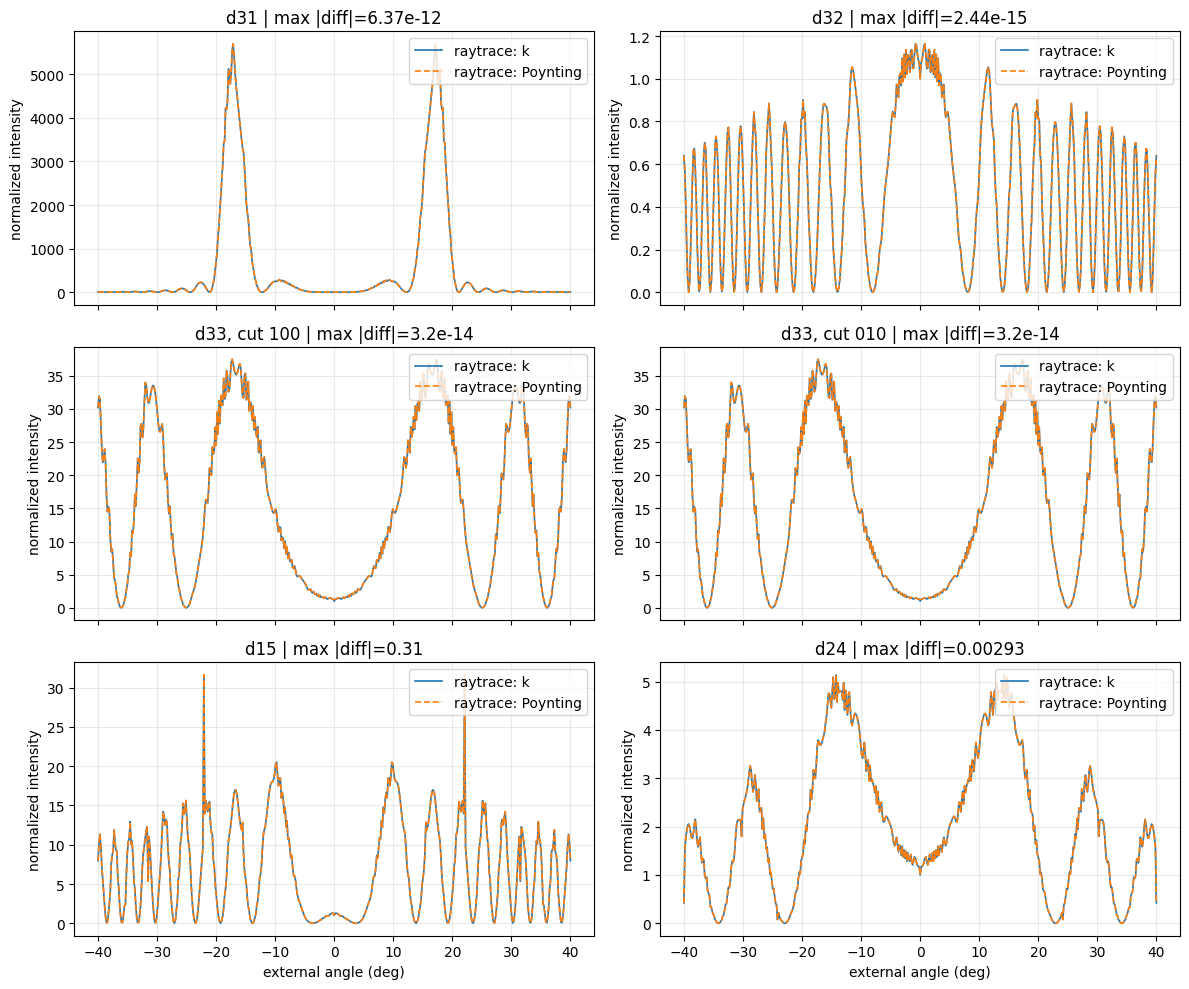

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True)
axes = axes.ravel()

direction_summary = []
for ax, config in zip(axes, BMF_CONFIGS):
    k_curve, k_aux = calculate_curve(
        config,
        use_raytrace=True,
        raytrace_beam_direction="k",
    )
    s_curve, s_aux = calculate_curve(
        config,
        use_raytrace=True,
        raytrace_beam_direction="poynting",
    )
    diff = s_curve - k_curve
    bin_diff = s_aux["raytrace_bin_width"] - k_aux["raytrace_bin_width"]
    factor_diff = s_aux["raytrace_factor"] - k_aux["raytrace_factor"]
    direction_summary.append(
        {
            "label": config["label"],
            "max_abs_curve_diff": float(np.nanmax(np.abs(diff))),
            "max_abs_bin_width_diff_mm": float(np.nanmax(np.abs(bin_diff))),
            "max_abs_raytrace_factor_diff": float(np.nanmax(np.abs(factor_diff))),
        }
    )

    ax.plot(THETA_DEG, k_curve, lw=1.2, label="raytrace: k")
    ax.plot(THETA_DEG, s_curve, lw=1.2, ls="--", label="raytrace: Poynting")
    ax.set_title(
        f"{config['label']} | max |diff|={np.nanmax(np.abs(diff)):.3g}"
    )
    ax.set_ylabel("normalized intensity")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper right")

for ax in axes[-2:]:
    ax.set_xlabel("external angle (deg)")

fig.tight_layout()
pd.DataFrame(direction_summary)


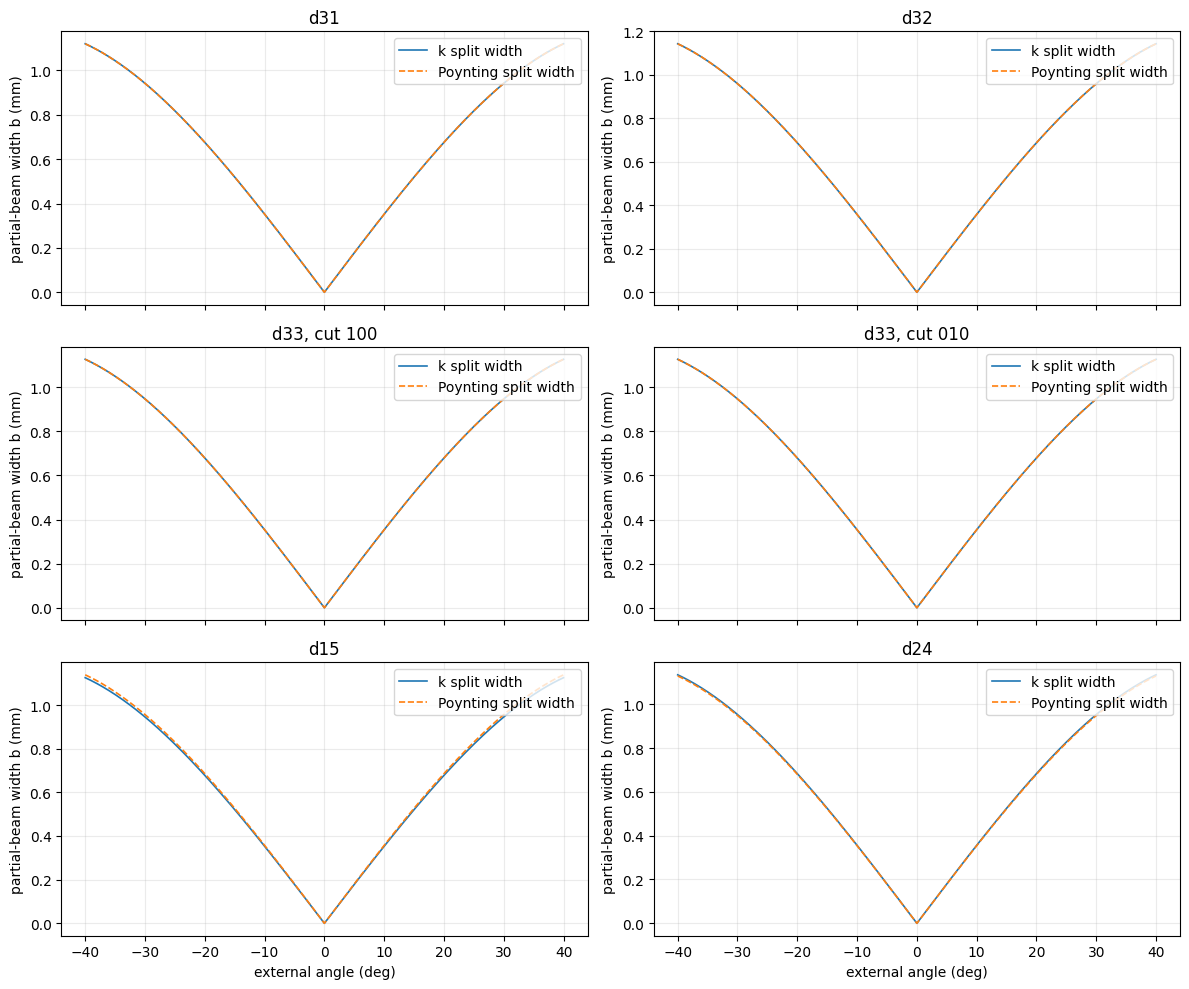

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True)
axes = axes.ravel()

for ax, config in zip(axes, BMF_CONFIGS):
    _, k_aux = calculate_curve(
        config,
        use_raytrace=True,
        raytrace_beam_direction="k",
    )
    _, s_aux = calculate_curve(
        config,
        use_raytrace=True,
        raytrace_beam_direction="poynting",
    )
    ax.plot(THETA_DEG, k_aux["raytrace_bin_width"], lw=1.2, label="k split width")
    ax.plot(THETA_DEG, s_aux["raytrace_bin_width"], lw=1.2, ls="--", label="Poynting split width")
    ax.set_title(config["label"])
    ax.set_ylabel("partial-beam width b (mm)")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper right")

for ax in axes[-2:]:
    ax.set_xlabel("external angle (deg)")

fig.tight_layout()


In [ ]:
summary = []
for config in BMF_CONFIGS:
    fringe, aux = calculate_curve(config, use_raytrace=True)
    summary.append(
        {
            "label": config["label"],
            "d_component": config["d_component"],
            "max_fringe": float(np.nanmax(fringe)),
            "d_factor": float(aux["d_factor"]),
            "raytrace_min": float(np.nanmin(aux["raytrace_factor"])),
            "raytrace_max": float(np.nanmax(aux["raytrace_factor"])),
        }
    )

pd.DataFrame(summary)

,label,d_component,max_fringe,d_factor,raytrace_min,raytrace_max
0,d31,d_31,5699.284098,4249.775491,0.926352,1.215811
1,d32,d_32,1.163837,518.621103,0.935325,1.191278
2,"d33, cut 100",d_33,37.500205,145.877804,0.923457,1.210222
3,"d33, cut 010",d_33,37.500205,145.877804,0.923457,1.210222
4,d15,d_15,31.319329,127.400255,0.629729,1.785008
5,d24,d_24,5.139777,25444.501868,0.479238,1.121353
